# HiRiD Circulatory Failure Prediction (Bootstrap Trajectories)

Bootstrap trajectory representation only. Compares model and feature configurations across single vs multi-biomarker trajectories and summary statistics.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

SEED = 920
np.random.seed(SEED)

print('✓ Imports successful')

✓ Imports successful


In [2]:
def _pick_id_col(df):
    for col in ['hadm_id', 'stay_id', 'patientid']:
        if col in df.columns:
            return col
    raise ValueError('No ID column found')


def _pick_time_cols(df):
    if 'time_hours' in df.columns and 'time_hour' in df.columns:
        return 'time_hours', 'time_hour'
    if 'time_days' in df.columns and 'time_day' in df.columns:
        return 'time_days', 'time_day'
    if 'time_hour' in df.columns:
        return 'time_hour', 'time_hour'
    if 'time_day' in df.columns:
        return 'time_day', 'time_day'
    raise ValueError('No time columns found')


def _read_table(path: Path) -> pd.DataFrame:
    if path.suffix == '.parquet':
        return pd.read_parquet(path)
    return pd.read_csv(path)


def _load_named_table(base_dir: Path, stem_name: str) -> pd.DataFrame:
    candidates = [base_dir / f'{stem_name}.parquet', base_dir / f'{stem_name}.csv']
    for p in candidates:
        if p.exists():
            print(f'  Using: {p}')
            return _read_table(p)
    raise FileNotFoundError(f'Missing table for {stem_name}. Tried: {candidates}')


base_candidates = [
    Path('../../../results/hirid/circulatory_failure'),
    Path('/home/gaga/data/physionet/hirid/circulatory_failure'),
]
BASE_DIR = next((p for p in base_candidates if p.exists()), base_candidates[0])
print(f'✓ BASE_DIR: {BASE_DIR}')

pred_stem_candidates = [
    'circulatory_failure_prediction_dataset_with_bootstrap_probs',
    'circulatory_failure_prediction_dataset',
]
for _stem in pred_stem_candidates:
    try:
        dataset = _load_named_table(BASE_DIR, _stem)
        pred_source_stem = _stem
        break
    except FileNotFoundError:
        continue
else:
    raise FileNotFoundError('Could not find prediction dataset (raw or pre-merged bootstrap version).')

print(f'✓ Loaded prediction dataset ({pred_source_stem}): {len(dataset):,} samples')

expected_traj_cols = [
    'lactate_stable', 'lactate_gradual', 'lactate_rapid',
    'heartrate_stable', 'heartrate_gradual', 'heartrate_rapid',
    'systolic_stable', 'systolic_gradual', 'systolic_rapid',
]
HAS_BOOTSTRAP_PROBS = all(c in dataset.columns for c in expected_traj_cols)
print(f'✓ Bootstrap trajectory features already present: {HAS_BOOTSTRAP_PROBS}')

lactate_ts = _load_named_table(BASE_DIR, 'lactate_timeseries')
heartrate_ts = _load_named_table(BASE_DIR, 'heartrate_timeseries')
systolic_ts = _load_named_table(BASE_DIR, 'systolic_timeseries')

print('✓ Loaded biomarker time series')
print(f"  Lactate:   {len(lactate_ts):,} rows")
print(f"  Heartrate: {len(heartrate_ts):,} rows")
print(f"  Systolic:  {len(systolic_ts):,} rows")

✓ BASE_DIR: /home/gaga/data/physionet/hirid/circulatory_failure
  Using: /home/gaga/data/physionet/hirid/circulatory_failure/circulatory_failure_prediction_dataset_with_bootstrap_probs.parquet
✓ Loaded prediction dataset (circulatory_failure_prediction_dataset_with_bootstrap_probs): 772,556 samples
✓ Bootstrap trajectory features already present: True
  Using: /home/gaga/data/physionet/hirid/circulatory_failure/lactate_timeseries.csv
  Using: /home/gaga/data/physionet/hirid/circulatory_failure/heartrate_timeseries.csv
  Using: /home/gaga/data/physionet/hirid/circulatory_failure/systolic_timeseries.csv
✓ Loaded biomarker time series
  Lactate:   258,906 rows
  Heartrate: 50,353,766 rows
  Systolic:  45,164,750 rows


In [3]:
LOOKBACK_HOURS = 12


def _load_bootstrap_trajectories(biomarker, output_stem):
    """
    Load pre-computed bootstrap trajectory probabilities.
    Expects merged files from:
      sbatch scripts/slurm/hirid/run_hirid_circulatory_failure_bootstrap.slurm
      bash scripts/slurm/hirid/merge_circulatory_failure_bootstrap.sh
    """
    boot_df = _load_named_table(BASE_DIR, output_stem)
    print(f"  Loaded {biomarker}: {len(boot_df):,} rows")

    id_col = 'patientid'
    windowing_col = 'time_hour'

    rename_map = {}
    for col in boot_df.columns:
        if col.endswith('_stable') and not col.startswith(biomarker):
            rename_map[col] = f'{biomarker}_stable'
        elif col.endswith('_gradual') and not col.startswith(biomarker):
            rename_map[col] = f'{biomarker}_gradual'
        elif col.endswith('_rapid') and not col.startswith(biomarker):
            rename_map[col] = f'{biomarker}_rapid'

    if rename_map:
        boot_df = boot_df.rename(columns=rename_map)

    expected_cols = [f'{biomarker}_stable', f'{biomarker}_gradual', f'{biomarker}_rapid']
    for col in expected_cols:
        if col not in boot_df.columns:
            boot_df[col] = np.nan

    keep_cols = [c for c in [id_col, windowing_col] + expected_cols if c in boot_df.columns]
    boot_df = boot_df[keep_cols].copy()

    key_cols = [id_col, windowing_col]
    dup_n = boot_df.duplicated(subset=key_cols).sum()
    if dup_n > 0:
        print(f"  WARNING: {biomarker} has {dup_n:,} duplicate key rows; aggregating mean probs")
        boot_df = boot_df.groupby(key_cols, as_index=False)[expected_cols].mean()

    return boot_df


if HAS_BOOTSTRAP_PROBS:
    print('Bootstrap trajectory probabilities already in prediction dataset; skipping external trajectory file loading.')
    lactate_boot = None
    heartrate_boot = None
    systolic_boot = None
else:
    print('Loading pre-computed bootstrap trajectory probabilities...')
    lactate_boot = _load_bootstrap_trajectories('lactate', 'lactate_trajectory_probs_bootstrap')
    heartrate_boot = _load_bootstrap_trajectories('heartrate', 'heartrate_trajectory_probs_bootstrap')
    systolic_boot = _load_bootstrap_trajectories('systolic', 'systolic_trajectory_probs_bootstrap')
    print('✓ Loaded bootstrap trajectory probabilities')

Bootstrap trajectory probabilities already in prediction dataset; skipping external trajectory file loading.


In [4]:
id_col = _pick_id_col(dataset)
_, windowing_col = _pick_time_cols(dataset)
key_cols = [id_col, windowing_col]


def _safe_left_merge(base_df, add_df, add_name):
    base_dup = base_df.duplicated(subset=key_cols).sum()
    add_dup = add_df.duplicated(subset=key_cols).sum()

    if base_dup > 0:
        print(f"WARNING: base dataset has {base_dup:,} duplicate keys; keeping first")
        base_df = base_df.drop_duplicates(subset=key_cols, keep='first')

    if add_dup > 0:
        prob_cols = [c for c in add_df.columns if c not in key_cols]
        print(f"WARNING: {add_name} has {add_dup:,} duplicate keys; aggregating means")
        add_df = add_df.groupby(key_cols, as_index=False)[prob_cols].mean()

    out = base_df.merge(add_df, on=key_cols, how='left', validate='one_to_one')
    return out


if not HAS_BOOTSTRAP_PROBS:
    dataset = _safe_left_merge(dataset, lactate_boot, 'lactate_boot')
    dataset = _safe_left_merge(dataset, heartrate_boot, 'heartrate_boot')
    dataset = _safe_left_merge(dataset, systolic_boot, 'systolic_boot')

for bm in ['lactate', 'heartrate', 'systolic']:
    for comp in ['stable', 'gradual', 'rapid']:
        col = f'{bm}_{comp}'
        if col not in dataset.columns:
            dataset[col] = np.nan

dataset['lactate_worsening'] = dataset['lactate_gradual'] + dataset['lactate_rapid']
dataset['heartrate_worsening'] = dataset['heartrate_gradual'] + dataset['heartrate_rapid']
dataset['systolic_worsening'] = dataset['systolic_gradual'] + dataset['systolic_rapid']
dataset['multi_marker_mean_worsening'] = dataset[['lactate_worsening', 'heartrate_worsening', 'systolic_worsening']].mean(axis=1)

print(f'✓ Dataset ready with trajectory probabilities: {len(dataset):,} samples')
print(f"✓ Unique merge keys: {dataset[key_cols].drop_duplicates().shape[0]:,}")

✓ Dataset ready with trajectory probabilities: 772,556 samples
✓ Unique merge keys: 772,556


In [5]:
from joblib import Parallel, delayed as jdelayed


def _patient_window_stats(id_val, pid_df, time_col, windowing_col, value_col, lookback_hours):
    """Compute windowed stats for a single patient using numpy arrays for speed."""
    pid_df = pid_df.sort_values(time_col)
    times = pid_df[time_col].to_numpy(dtype=float)
    values = pid_df[value_col].to_numpy(dtype=float)
    unique_hours = np.unique(pid_df[windowing_col].to_numpy())

    rows = []
    for h in unique_hours:
        mask = (times >= h - lookback_hours) & (times <= h)
        wv = values[mask]
        wt = times[mask]
        n = len(wv)
        if n == 0:
            rows.append((id_val, h, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan))
        else:
            rows.append((
                id_val, h,
                float(np.mean(wv)),
                float(np.max(wv)),
                float(np.min(wv)),
                float(wv[-1] - wv[0]),
                float(np.polyfit(wt, wv, 1)[0]) if n > 1 else 0.0,
                float(np.std(wv)) if n > 1 else 0.0,
            ))
    return rows


def biomarker_summary_stats(ts_df, value_col, lookback_hours=12, n_jobs=4):
    loc_id_col = _pick_id_col(ts_df)
    time_col, wc = _pick_time_cols(ts_df)
    suffix = f'_{lookback_hours}h'

    df = ts_df[[loc_id_col, time_col, wc, value_col]].copy()
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    df = df.dropna(subset=[value_col])

    # Deduplicate exact (patient, time) duplicates — average the value
    n_before = len(df)
    dup_exact = df.duplicated(subset=[loc_id_col, time_col]).sum()
    if dup_exact > 0:
        df = df.groupby([loc_id_col, time_col], as_index=False).agg(
            {wc: 'first', value_col: 'mean'}
        )
        print(f'    Removed {dup_exact:,} exact duplicate (patient, time) rows ({n_before:,} → {len(df):,})')

    groups_list = list(df.groupby(loc_id_col))
    print(f'    {len(groups_list):,} patients (n_jobs={n_jobs})...')

    nested = Parallel(n_jobs=n_jobs)(
        jdelayed(_patient_window_stats)(pid, gdf, time_col, wc, value_col, lookback_hours)
        for pid, gdf in groups_list
    )

    all_rows = [r for sublist in nested for r in sublist]

    cols = [
        loc_id_col, wc,
        f'{value_col}_mean{suffix}', f'{value_col}_max{suffix}', f'{value_col}_min{suffix}',
        f'{value_col}_change{suffix}', f'{value_col}_trend{suffix}', f'{value_col}_std{suffix}',
    ]
    out = pd.DataFrame(all_rows, columns=cols)
    out = out.drop_duplicates(subset=[loc_id_col, wc], keep='last')
    return out


print(f'Computing summary statistics (lookback={LOOKBACK_HOURS} hours)...')
print('Lactate:')
lactate_sum_df = biomarker_summary_stats(lactate_ts, 'lactate', lookback_hours=LOOKBACK_HOURS)
print('Heartrate:')
heartrate_sum_df = biomarker_summary_stats(heartrate_ts, 'heartrate', lookback_hours=LOOKBACK_HOURS)
print('Systolic:')
systolic_sum_df = biomarker_summary_stats(systolic_ts, 'systolic', lookback_hours=LOOKBACK_HOURS)

dataset = _safe_left_merge(dataset, lactate_sum_df, 'lactate_summary')
dataset = _safe_left_merge(dataset, heartrate_sum_df, 'heartrate_summary')
dataset = _safe_left_merge(dataset, systolic_sum_df, 'systolic_summary')

print('✓ Added summary statistics')
print(f'  Summary columns added: {[c for c in dataset.columns if c.endswith(f"_{LOOKBACK_HOURS}h")]}')

Computing summary statistics (lookback=12 hours)...
Lactate:
    Removed 67,517 exact duplicate (patient, time) rows (258,906 → 191,389)
    15,613 patients (n_jobs=4)...
Heartrate:
    Removed 15,818 exact duplicate (patient, time) rows (50,353,766 → 50,337,948)
    16,895 patients (n_jobs=4)...
Systolic:
    Removed 38,472 exact duplicate (patient, time) rows (45,164,750 → 45,126,278)
    16,895 patients (n_jobs=4)...
✓ Added summary statistics
  Summary columns added: ['lactate_mean_12h', 'lactate_max_12h', 'lactate_min_12h', 'lactate_change_12h', 'lactate_trend_12h', 'lactate_std_12h', 'heartrate_mean_12h', 'heartrate_max_12h', 'heartrate_min_12h', 'heartrate_change_12h', 'heartrate_trend_12h', 'heartrate_std_12h', 'systolic_mean_12h', 'systolic_max_12h', 'systolic_min_12h', 'systolic_change_12h', 'systolic_trend_12h', 'systolic_std_12h']


In [6]:
target_col = next((c for c in ['target_circulatory_failure', 'target_circ_failure', 'target_circulatory'] if c in dataset.columns), None)
if target_col is None:
    raise ValueError('No target column found')

if 'gender' in dataset.columns:
    gender_map = {'M': 1, 'F': 0}
    dataset['gender'] = dataset['gender'].map(gender_map)

static_features = [c for c in ['age', 'gender'] if c in dataset.columns]

exclude_keywords = ['stable', 'gradual', 'rapid', 'worsening', 'marker', 'trend', 'change', 'boot']
dynamic_labs = [
    col for col in dataset.columns
    if any(col.startswith(prefix) for prefix in ['min_', 'mean_', 'max_'])
    and not any(keyword in col.lower() for keyword in exclude_keywords)
]
dynamic_vitals = [
    col for col in dataset.columns
    if any(x in col for x in ['heart_rate', 'respiratory_rate', 'o2_sat', 'systolic', 'diastolic', 'mean_bp', 'temperature'])
]
dynamic_features = list(dict.fromkeys(dynamic_labs + dynamic_vitals))

lactate_traj = ['lactate_stable', 'lactate_gradual', 'lactate_rapid', 'lactate_worsening']
heartrate_traj = ['heartrate_stable', 'heartrate_gradual', 'heartrate_rapid', 'heartrate_worsening']
systolic_traj = ['systolic_stable', 'systolic_gradual', 'systolic_rapid', 'systolic_worsening']
multi_traj = lactate_traj + heartrate_traj + systolic_traj + ['multi_marker_mean_worsening']

lactate_summary = [c for c in dataset.columns if c.startswith('lactate_') and c.endswith('h')]
heartrate_summary = [c for c in dataset.columns if c.startswith('heartrate_') and c.endswith('h')]
systolic_summary = [c for c in dataset.columns if c.startswith('systolic_') and c.endswith('h')]
multi_summary = lactate_summary + heartrate_summary + systolic_summary

baseline_features = static_features + dynamic_features
if len(baseline_features) == 0:
    baseline_features = static_features


def _present(cols):
    return [c for c in list(dict.fromkeys(cols)) if c in dataset.columns]


feature_sets = {
    'Baseline': _present(baseline_features),
    'Baseline + Single Trajectory': _present(baseline_features + lactate_traj),
    'Baseline + Multi Trajectory': _present(baseline_features + multi_traj),
    'Baseline + Single Summary': _present(baseline_features + lactate_summary),
    'Baseline + Multi Summary': _present(baseline_features + multi_summary),
    'Baseline + Single Trajectory + Summary': _present(baseline_features + lactate_traj + lactate_summary),
    'Baseline + Multi Trajectory + Summary': _present(baseline_features + multi_traj + multi_summary),
}

feature_sets = {k: v for k, v in feature_sets.items() if len(v) > 0}

print(f'Target column: {target_col}')
print(f'Feature sets prepared: {len(feature_sets)} total')
for k, v in feature_sets.items():
    print(f'  {k}: {len(v)} features')

Target column: target_circulatory_failure
Feature sets prepared: 7 total
  Baseline: 25 features
  Baseline + Single Trajectory: 29 features
  Baseline + Multi Trajectory: 34 features
  Baseline + Single Summary: 31 features
  Baseline + Multi Summary: 37 features
  Baseline + Single Trajectory + Summary: 35 features
  Baseline + Multi Trajectory + Summary: 46 features


In [ ]:
EVAL_PROFILE = 'full'  # 'quick' or 'full'
MAX_ROWS_QUICK = 250_000

dataset_clean = dataset.dropna(subset=[target_col]).copy()

if EVAL_PROFILE == 'quick' and len(dataset_clean) > MAX_ROWS_QUICK:
    rng = np.random.default_rng(SEED)
    sample_idx = rng.choice(dataset_clean.index.values, size=MAX_ROWS_QUICK, replace=False)
    dataset_clean = dataset_clean.loc[sample_idx].copy()
    print(f'Quick profile: sampled {len(dataset_clean):,} rows from full dataset')

y = dataset_clean[target_col].astype(int)
groups = dataset_clean[id_col]

traj_cols = [c for c in dataset_clean.columns if any(k in c for k in ['_stable', '_gradual', '_rapid', '_worsening'])]
summary_cols = [
    c for c in dataset_clean.columns
    if c.endswith('h') and any(prefix in c for prefix in ['lactate_', 'heartrate_', 'systolic_'])
]

# Forward-fill trajectory features (up to 2 consecutive missing) to reduce NaN
# Mirrors the imputation strategy used in the eICU sepsis analysis notebook
print(f"Before ffill — trajectory NaN: {dataset_clean[traj_cols].isna().sum().sum():,}")
dataset_clean[traj_cols] = dataset_clean.groupby(id_col)[traj_cols].ffill(limit=2)
print(f"After ffill  — trajectory NaN: {dataset_clean[traj_cols].isna().sum().sum():,}")
print(f"Summary cols NaN:              {dataset_clean[summary_cols].isna().sum().sum():,}")

# Boosting models (XGBoost, HistGBM) handle NaN natively; non-boosting models need
# explicit imputation. This mirrors the eICU sepsis analysis notebook pattern.
BOOSTING_MODELS = {'XGBoost', 'Gradient Boosting'}

models_to_evaluate = {
    'XGBoost': lambda pos_weight, seed: XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        scale_pos_weight=pos_weight,
        random_state=seed,
        eval_metric='logloss'
    ),
    'Logistic Regression': lambda pos_weight, seed: LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=seed,
        solver='lbfgs'
    ),
    'Random Forest': lambda pos_weight, seed: RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight='balanced',
        random_state=seed,
        n_jobs=4
    ),
    'Gradient Boosting': lambda pos_weight, seed: HistGradientBoostingClassifier(
        max_bins=225,
        max_depth=3,
        learning_rate=0.1,
        random_state=seed
    )
}

if EVAL_PROFILE == 'quick':
    n_repeats = 2
    n_folds = 3
else:
    n_repeats = 10
    n_folds = 5

fold_rows = []
pred_rows = []
calibration_feature_sets = {'Baseline', 'Baseline + Multi Trajectory', 'Baseline + Multi Trajectory + Summary'}

print(f"\nStarting CV: models={len(models_to_evaluate)}, feature_sets={len(feature_sets)}, repeats={n_repeats}, folds={n_folds}")

for model_name, model_fn in models_to_evaluate.items():
    print(f"\n{'=' * 80}")
    print(f"Model: {model_name}")
    print(f"{'=' * 80}")

    # Per-model dataset copy with NaN strategy matched to the eICU sepsis analysis notebook:
    #   Non-boosting (LR, RF)  → fill traj/summary NaN with 0, then median imputer per fold
    #   Boosting (XGBoost, GBM) → keep NaN; models handle missingness natively
    dataset_model = dataset_clean.copy()
    if model_name not in BOOSTING_MODELS:
        dataset_model[traj_cols] = dataset_model[traj_cols].fillna(0)
        dataset_model[summary_cols] = dataset_model[summary_cols].fillna(0)

    for feature_set_name, feature_cols in feature_sets.items():
        print(f"  -> Feature set: {feature_set_name} ({len(feature_cols)} features)")

        fs_auc = []
        fs_aupr = []

        for repeat in range(n_repeats):
            rng = np.random.RandomState(seed=SEED + repeat)
            shuffle_idx = rng.permutation(len(dataset_model))

            dataset_repeat = dataset_model.iloc[shuffle_idx].reset_index(drop=True)
            y_repeat = y.iloc[shuffle_idx].reset_index(drop=True)
            groups_repeat = groups.iloc[shuffle_idx].reset_index(drop=True)

            gkf = GroupKFold(n_splits=n_folds)
            rep_auc = []
            rep_aupr = []

            for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(dataset_repeat, y_repeat, groups_repeat), start=1):
                X_train = dataset_repeat.iloc[train_idx][feature_cols]
                X_test = dataset_repeat.iloc[test_idx][feature_cols]
                y_train = y_repeat.iloc[train_idx]
                y_test = y_repeat.iloc[test_idx]

                if model_name not in BOOSTING_MODELS:
                    # Impute remaining NaN using training data only (prevents leakage)
                    imputer = SimpleImputer(strategy='median')
                    X_train_imputed = imputer.fit_transform(X_train)
                    X_test_imputed = imputer.transform(X_test)
                else:
                    # Boosting models handle NaN natively; pass arrays directly
                    X_train_imputed = X_train
                    X_test_imputed = X_test

                # Scale features (all models)
                scaler = StandardScaler()
                X_train_proc = scaler.fit_transform(X_train_imputed)
                X_test_proc = scaler.transform(X_test_imputed)

                pos = y_train.sum()
                neg = len(y_train) - pos
                scale_pos_weight = neg / max(pos, 1)

                model = model_fn(scale_pos_weight, SEED + repeat)
                model.fit(X_train_proc, y_train)

                y_pred_proba = model.predict_proba(X_test_proc)[:, 1]

                auc = roc_auc_score(y_test, y_pred_proba)
                aupr = average_precision_score(y_test, y_pred_proba)
                rep_auc.append(auc)
                rep_aupr.append(aupr)
                fs_auc.append(auc)
                fs_aupr.append(aupr)

                fold_rows.append({
                    'Model': model_name,
                    'Feature Set': feature_set_name,
                    'repeat': repeat + 1,
                    'fold': fold_idx,
                    'n_features': len(feature_cols),
                    'n_train': len(train_idx),
                    'n_test': len(test_idx),
                    'pos_rate_test': float(y_test.mean()),
                    'ROC-AUC': auc,
                    'AUPR': aupr,
                })

                if feature_set_name in calibration_feature_sets:
                    pred_rows.append(pd.DataFrame({
                        'Model': model_name,
                        'Feature Set': feature_set_name,
                        'repeat': repeat + 1,
                        'fold': fold_idx,
                        'y_true': y_test.values,
                        'y_pred': y_pred_proba,
                    }))

            print(
                f"     repeat {repeat + 1:02d}/{n_repeats}: "
                f"AUROC={np.mean(rep_auc):.4f} | AUPR={np.mean(rep_aupr):.4f}"
            )

        print(
            f"     done {feature_set_name}: "
            f"AUROC={np.mean(fs_auc):.4f}±{np.std(fs_auc):.4f} | "
            f"AUPR={np.mean(fs_aupr):.4f}±{np.std(fs_aupr):.4f}"
        )

results_df = pd.DataFrame(fold_rows)
pred_df = pd.concat(pred_rows, ignore_index=True) if pred_rows else pd.DataFrame()

summary_df = (
    results_df
    .groupby(['Model', 'Feature Set'], as_index=False)
    .agg(
        ROC_AUC_mean=('ROC-AUC', 'mean'),
        ROC_AUC_std=('ROC-AUC', 'std'),
        AUPR_mean=('AUPR', 'mean'),
        AUPR_std=('AUPR', 'std'),
        n_folds=('ROC-AUC', 'count')
    )
)

baseline_metrics = (
    results_df[results_df['Feature Set'] == 'Baseline'][['Model', 'repeat', 'fold', 'ROC-AUC', 'AUPR']]
    .rename(columns={'ROC-AUC': 'Baseline ROC-AUC', 'AUPR': 'Baseline AUPR'})
)

delta_df = results_df.merge(baseline_metrics, on=['Model', 'repeat', 'fold'], how='left', validate='many_to_one')
delta_df['Delta ROC-AUC'] = delta_df['ROC-AUC'] - delta_df['Baseline ROC-AUC']
delta_df['Delta AUPR'] = delta_df['AUPR'] - delta_df['Baseline AUPR']

delta_summary_df = (
    delta_df[delta_df['Feature Set'] != 'Baseline']
    .groupby(['Model', 'Feature Set'], as_index=False)
    .agg(
        Delta_ROC_AUC_mean=('Delta ROC-AUC', 'mean'),
        Delta_ROC_AUC_std=('Delta ROC-AUC', 'std'),
        Delta_AUPR_mean=('Delta AUPR', 'mean'),
        Delta_AUPR_std=('Delta AUPR', 'std'),
        n_folds=('Delta ROC-AUC', 'count')
    )
)

print('\n✓ Finished model comparisons')
print(f'Eval profile: {EVAL_PROFILE} | repeats={n_repeats}, folds={n_folds}')
print(f'Fold-level rows: {len(results_df):,}')
print(f'Prediction rows (for calibration): {len(pred_df):,}')


Before ffill — trajectory NaN: 2,977,266
After ffill  — trajectory NaN: 2,775,327
Summary cols NaN:              4,353,888

Starting CV: models=4, feature_sets=7, repeats=10, folds=5

Model: XGBoost
  -> Feature set: Baseline (25 features)
     repeat 01/10: AUROC=0.9326 | AUPR=0.2926
     repeat 02/10: AUROC=0.9328 | AUPR=0.2920
     repeat 03/10: AUROC=0.9328 | AUPR=0.2934
     repeat 04/10: AUROC=0.9327 | AUPR=0.2925
     repeat 05/10: AUROC=0.9327 | AUPR=0.2936
     repeat 06/10: AUROC=0.9327 | AUPR=0.2943
     repeat 07/10: AUROC=0.9326 | AUPR=0.2933
     repeat 08/10: AUROC=0.9326 | AUPR=0.2940
     repeat 09/10: AUROC=0.9327 | AUPR=0.2929
     repeat 10/10: AUROC=0.9330 | AUPR=0.2926
     done Baseline: AUROC=0.9327±0.0062 | AUPR=0.2931±0.0113
  -> Feature set: Baseline + Single Trajectory (29 features)
     repeat 01/10: AUROC=0.9333 | AUPR=0.2977
     repeat 02/10: AUROC=0.9333 | AUPR=0.2973
     repeat 03/10: AUROC=0.9332 | AUPR=0.2984
     repeat 04/10: AUROC=0.9333 | AUPR=0

In [ ]:
summary_view = summary_df.sort_values(['Model', 'ROC_AUC_mean'], ascending=[True, False]).copy()
delta_view = delta_summary_df.sort_values(['Model', 'Delta_ROC_AUC_mean'], ascending=[True, False]).copy()

print('Top absolute performance by model:')
display(summary_view.groupby('Model', group_keys=False).head(7))

print('Top incremental gain vs Baseline by model:')
display(delta_view.groupby('Model', group_keys=False).head(7))

Top absolute performance by model:


,Model,Feature Set,ROC_AUC_mean,ROC_AUC_std,AUPR_mean,AUPR_std,n_folds
3,Gradient Boosting,Baseline + Multi Trajectory + Summary,0.926232,0.007680,0.322934,0.041659,6
1,Gradient Boosting,Baseline + Multi Summary,0.925279,0.007429,0.324793,0.042600,6
4,Gradient Boosting,Baseline + Single Summary,0.924428,0.008706,0.320854,0.043787,6
6,Gradient Boosting,Baseline + Single Trajectory + Summary,0.924308,0.008849,0.321208,0.044406,6
2,Gradient Boosting,Baseline + Multi Trajectory,0.922546,0.008114,0.277894,0.034778,6
5,Gradient Boosting,Baseline + Single Trajectory,0.922507,0.008297,0.279917,0.036282,6
0,Gradient Boosting,Baseline,0.922425,0.007733,0.274910,0.036539,6
10,Logistic Regression,Baseline + Multi Trajectory + Summary,0.859794,0.009568,0.126439,0.025663,6
8,Logistic Regression,Baseline + Multi Summary,0.859262,0.009264,0.121663,0.023952,6
13,Logistic Regression,Baseline + Single Trajectory + Summary,0.858421,0.008635,0.113788,0.022621,6


Top incremental gain vs Baseline by model:


,Model,Feature Set,Delta_ROC_AUC_mean,Delta_ROC_AUC_std,Delta_AUPR_mean,Delta_AUPR_std,n_folds
2,Gradient Boosting,Baseline + Multi Trajectory + Summary,0.003806,0.002238,0.048024,0.012664,6
0,Gradient Boosting,Baseline + Multi Summary,0.002854,0.001905,0.049883,0.014020,6
3,Gradient Boosting,Baseline + Single Summary,0.002002,0.001890,0.045944,0.014877,6
5,Gradient Boosting,Baseline + Single Trajectory + Summary,0.001882,0.001682,0.046298,0.015948,6
1,Gradient Boosting,Baseline + Multi Trajectory,0.000121,0.000854,0.002984,0.003781,6
4,Gradient Boosting,Baseline + Single Trajectory,0.000081,0.001143,0.005007,0.003556,6
8,Logistic Regression,Baseline + Multi Trajectory + Summary,0.025243,0.003213,-0.047622,0.007249,6
6,Logistic Regression,Baseline + Multi Summary,0.024712,0.004423,-0.052398,0.007721,6
11,Logistic Regression,Baseline + Single Trajectory + Summary,0.023871,0.001091,-0.060274,0.008488,6
9,Logistic Regression,Baseline + Single Summary,0.023079,0.001232,-0.063837,0.009754,6


In [ ]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

try:
    from scipy.stats import wilcoxon
    _has_scipy = True
except Exception:
    _has_scipy = False


def _bootstrap_ci(x, n_boot=2000, alpha=0.05, seed=920):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    samples = rng.choice(x, size=(n_boot, x.size), replace=True).mean(axis=1)
    lo = np.quantile(samples, alpha / 2)
    hi = np.quantile(samples, 1 - alpha / 2)
    return float(lo), float(hi)


infer_rows = []
for (model_name, feature_set_name), g in delta_df[delta_df['Feature Set'] != 'Baseline'].groupby(['Model', 'Feature Set']):
    d_auc = g['Delta ROC-AUC'].values
    d_aupr = g['Delta AUPR'].values

    auc_lo, auc_hi = _bootstrap_ci(d_auc)
    aupr_lo, aupr_hi = _bootstrap_ci(d_aupr)

    if _has_scipy:
        try:
            p_auc = wilcoxon(d_auc, alternative='greater').pvalue
        except Exception:
            p_auc = np.nan
        try:
            p_aupr = wilcoxon(d_aupr, alternative='greater').pvalue
        except Exception:
            p_aupr = np.nan
    else:
        p_auc = np.nan
        p_aupr = np.nan

    infer_rows.append({
        'Model': model_name,
        'Feature Set': feature_set_name,
        'Delta_ROC_AUC_mean': float(np.mean(d_auc)),
        'Delta_ROC_AUC_CI_low': auc_lo,
        'Delta_ROC_AUC_CI_high': auc_hi,
        'Delta_AUPR_mean': float(np.mean(d_aupr)),
        'Delta_AUPR_CI_low': aupr_lo,
        'Delta_AUPR_CI_high': aupr_hi,
        'p_wilcoxon_auc_greater_0': p_auc,
        'p_wilcoxon_aupr_greater_0': p_aupr,
        'n_folds': int(len(g)),
    })

inference_df = pd.DataFrame(infer_rows).sort_values(['Model', 'Delta_ROC_AUC_mean'], ascending=[True, False])

print('Inferential summary (delta vs baseline):')
display(inference_df.head(20))

if not _has_scipy:
    print('NOTE: scipy not available; Wilcoxon p-values are NaN.')

Inferential summary (delta vs baseline):


,Model,Feature Set,Delta_ROC_AUC_mean,Delta_ROC_AUC_CI_low,Delta_ROC_AUC_CI_high,Delta_AUPR_mean,Delta_AUPR_CI_low,Delta_AUPR_CI_high,p_wilcoxon_auc_greater_0,p_wilcoxon_aupr_greater_0,n_folds
2,Gradient Boosting,Baseline + Multi Trajectory + Summary,0.003806,0.002255,0.005581,0.048024,0.039775,0.057827,0.015625,0.015625,6
0,Gradient Boosting,Baseline + Multi Summary,0.002854,0.001511,0.004269,0.049883,0.040370,0.060991,0.015625,0.015625,6
3,Gradient Boosting,Baseline + Single Summary,0.002002,0.000885,0.003574,0.045944,0.035593,0.057244,0.015625,0.015625,6
5,Gradient Boosting,Baseline + Single Trajectory + Summary,0.001882,0.000692,0.003148,0.046298,0.035939,0.058881,0.015625,0.015625,6
1,Gradient Boosting,Baseline + Multi Trajectory,0.000121,-0.000603,0.000627,0.002984,0.000206,0.005598,0.281250,0.078125,6
4,Gradient Boosting,Baseline + Single Trajectory,0.000081,-0.000724,0.000965,0.005007,0.002200,0.007422,0.500000,0.031250,6
8,Logistic Regression,Baseline + Multi Trajectory + Summary,0.025243,0.022851,0.027636,-0.047622,-0.052936,-0.042309,0.015625,1.000000,6
6,Logistic Regression,Baseline + Multi Summary,0.024712,0.021667,0.027757,-0.052398,-0.057630,-0.047167,0.015625,1.000000,6
11,Logistic Regression,Baseline + Single Trajectory + Summary,0.023871,0.023131,0.024614,-0.060274,-0.065915,-0.054633,0.015625,1.000000,6
9,Logistic Regression,Baseline + Single Summary,0.023079,0.022175,0.023983,-0.063837,-0.070684,-0.056987,0.015625,1.000000,6


Calibration summary (lower Brier is better):


,Model,Feature Set,Brier,Prevalence,n
2,Gradient Boosting,Baseline + Multi Trajectory + Summary,0.006560,0.00818,500000
1,Gradient Boosting,Baseline + Multi Trajectory,0.006882,0.00818,500000
0,Gradient Boosting,Baseline,0.006892,0.00818,500000
5,Logistic Regression,Baseline + Multi Trajectory + Summary,0.125889,0.00818,500000
4,Logistic Regression,Baseline + Multi Trajectory,0.136315,0.00818,500000
3,Logistic Regression,Baseline,0.140682,0.00818,500000
8,Random Forest,Baseline + Multi Trajectory + Summary,0.026095,0.00818,500000
7,Random Forest,Baseline + Multi Trajectory,0.027477,0.00818,500000
6,Random Forest,Baseline,0.029145,0.00818,500000
11,XGBoost,Baseline + Multi Trajectory + Summary,0.068181,0.00818,500000


Threshold utility summary:


,Model,Feature Set,threshold,Sensitivity,Specificity,PPV,NPV
0,Gradient Boosting,Baseline,0.1,0.406112,0.992184,0.299982,0.995088
1,Gradient Boosting,Baseline,0.2,0.315648,0.996038,0.396499,0.994365
2,Gradient Boosting,Baseline,0.3,0.259413,0.997479,0.459109,0.993914
3,Gradient Boosting,Baseline + Multi Trajectory,0.1,0.408802,0.992079,0.298571,0.995109
4,Gradient Boosting,Baseline + Multi Trajectory,0.2,0.318826,0.996032,0.398533,0.994391
5,Gradient Boosting,Baseline + Multi Trajectory,0.3,0.260147,0.997493,0.461205,0.993920
6,Gradient Boosting,Baseline + Multi Trajectory + Summary,0.1,0.466504,0.991505,0.311714,0.995582
7,Gradient Boosting,Baseline + Multi Trajectory + Summary,0.2,0.358924,0.996326,0.446201,0.994721
8,Gradient Boosting,Baseline + Multi Trajectory + Summary,0.3,0.288998,0.997863,0.527208,0.994158
9,Logistic Regression,Baseline,0.1,0.986797,0.109193,0.009053,0.999004


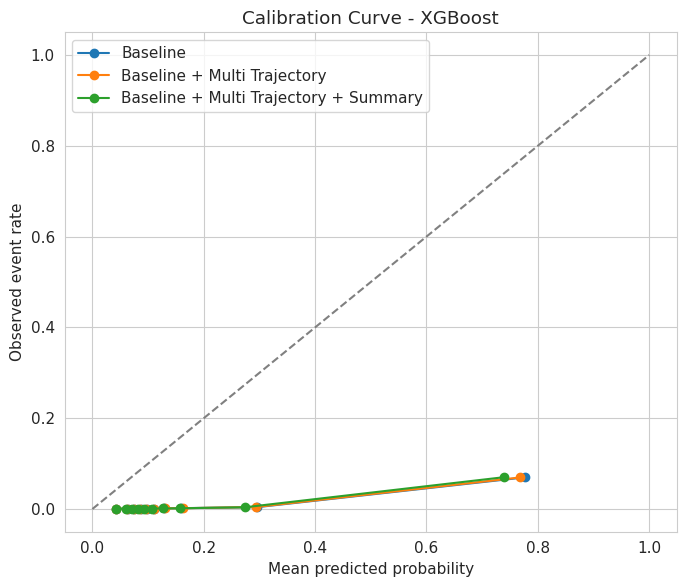

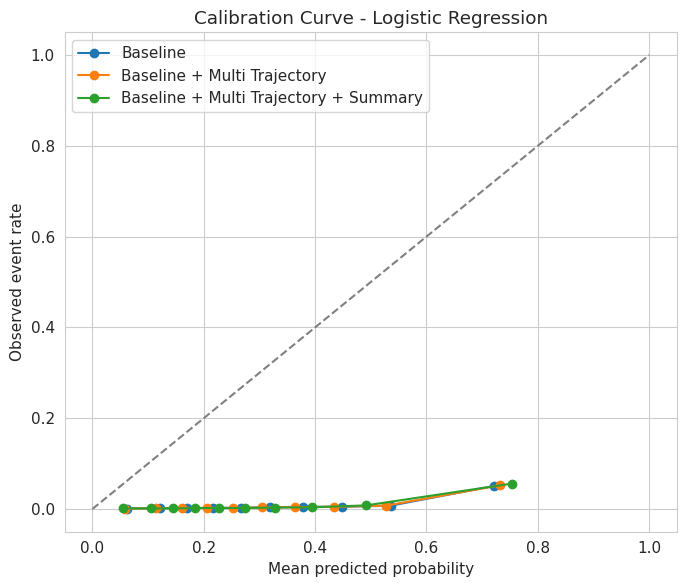

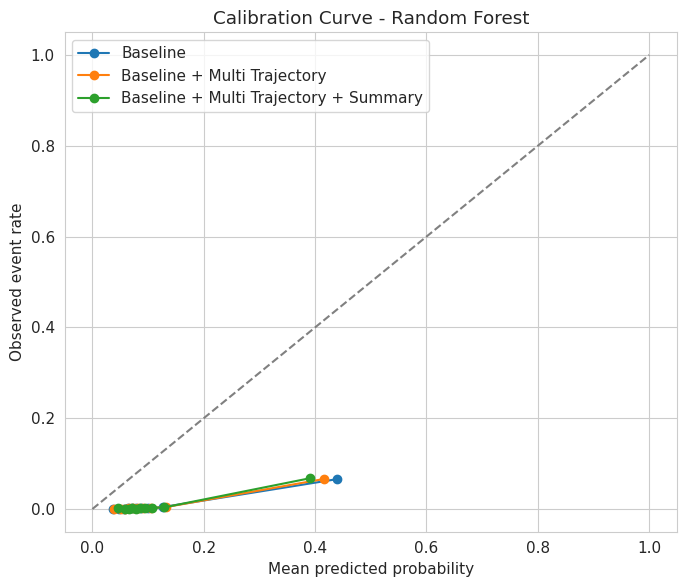

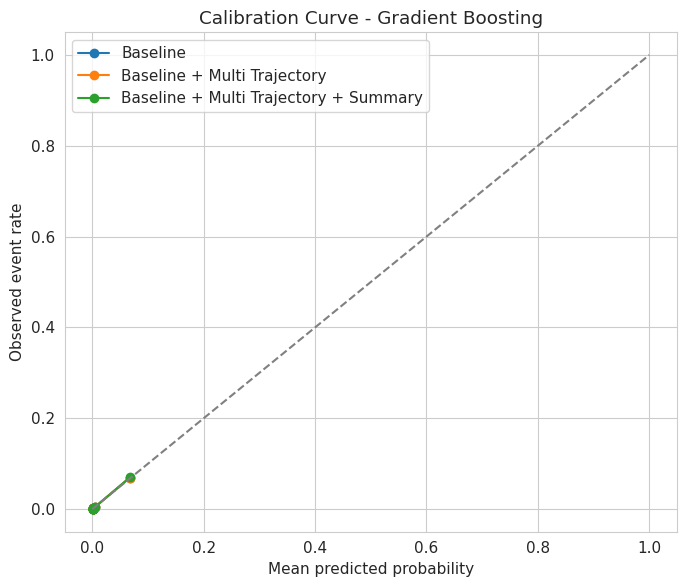

In [ ]:
# Calibration and threshold utility (for selected feature sets)
if pred_df.empty:
    print('No prediction rows available for calibration analysis.')
else:
    cal_rows = []
    threshold_rows = []

    for (model_name, feature_set_name), g in pred_df.groupby(['Model', 'Feature Set']):
        y_true = g['y_true'].values.astype(int)
        y_pred = g['y_pred'].values.astype(float)

        brier = brier_score_loss(y_true, y_pred)
        cal_rows.append({
            'Model': model_name,
            'Feature Set': feature_set_name,
            'Brier': brier,
            'Prevalence': float(y_true.mean()),
            'n': int(len(g)),
        })

        for thr in [0.10, 0.20, 0.30]:
            y_hat = (y_pred >= thr).astype(int)
            tp = int(((y_hat == 1) & (y_true == 1)).sum())
            fp = int(((y_hat == 1) & (y_true == 0)).sum())
            fn = int(((y_hat == 0) & (y_true == 1)).sum())
            tn = int(((y_hat == 0) & (y_true == 0)).sum())

            sens = tp / max(tp + fn, 1)
            spec = tn / max(tn + fp, 1)
            ppv = tp / max(tp + fp, 1)
            npv = tn / max(tn + fn, 1)

            threshold_rows.append({
                'Model': model_name,
                'Feature Set': feature_set_name,
                'threshold': thr,
                'Sensitivity': sens,
                'Specificity': spec,
                'PPV': ppv,
                'NPV': npv,
            })

    calibration_summary_df = pd.DataFrame(cal_rows).sort_values(['Model', 'Brier'])
    threshold_summary_df = pd.DataFrame(threshold_rows)

    print('Calibration summary (lower Brier is better):')
    display(calibration_summary_df)

    print('Threshold utility summary:')
    display(threshold_summary_df.head(30))

    # Reliability plots
    for model_name in pred_df['Model'].unique():
        plt.figure(figsize=(7, 6))
        model_sub = pred_df[pred_df['Model'] == model_name]
        for feature_set_name in sorted(model_sub['Feature Set'].unique()):
            g = model_sub[model_sub['Feature Set'] == feature_set_name]
            frac_pos, mean_pred = calibration_curve(g['y_true'], g['y_pred'], n_bins=10, strategy='quantile')
            plt.plot(mean_pred, frac_pos, marker='o', label=feature_set_name)

        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title(f'Calibration Curve - {model_name}')
        plt.xlabel('Mean predicted probability')
        plt.ylabel('Observed event rate')
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

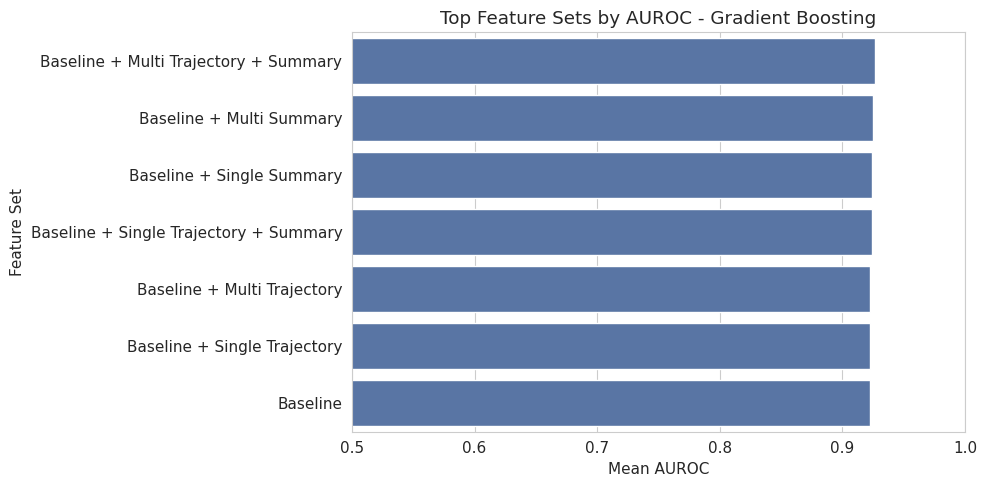

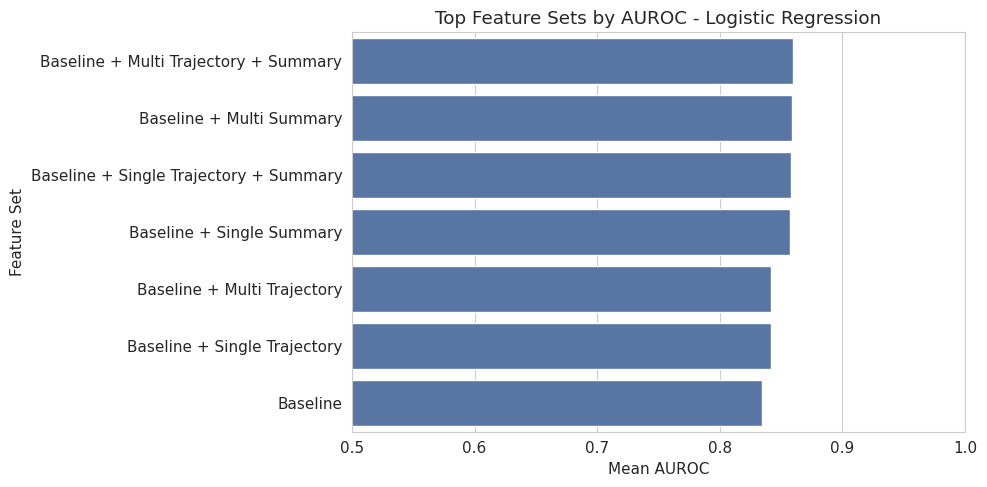

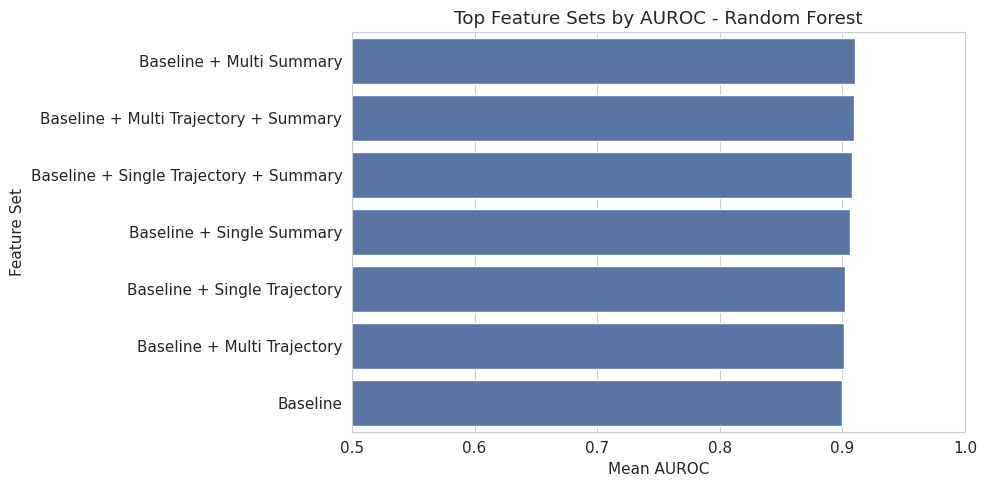

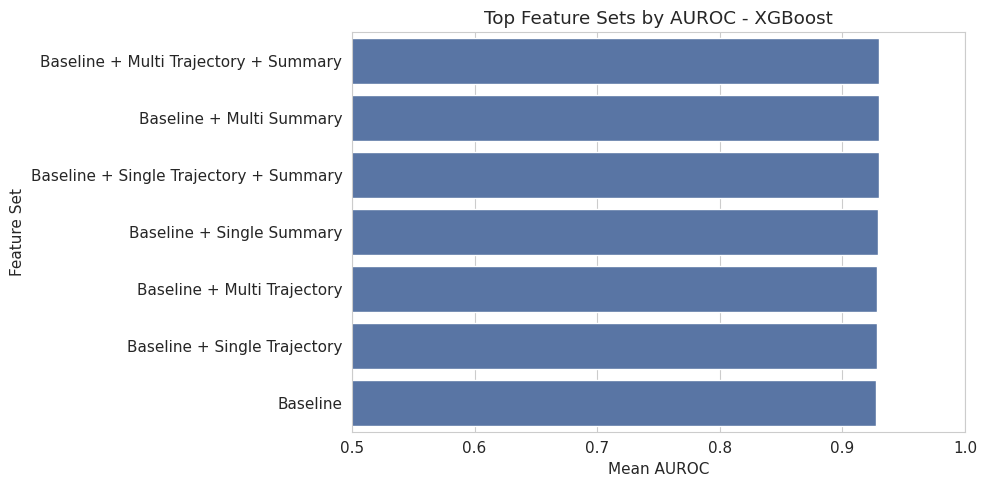

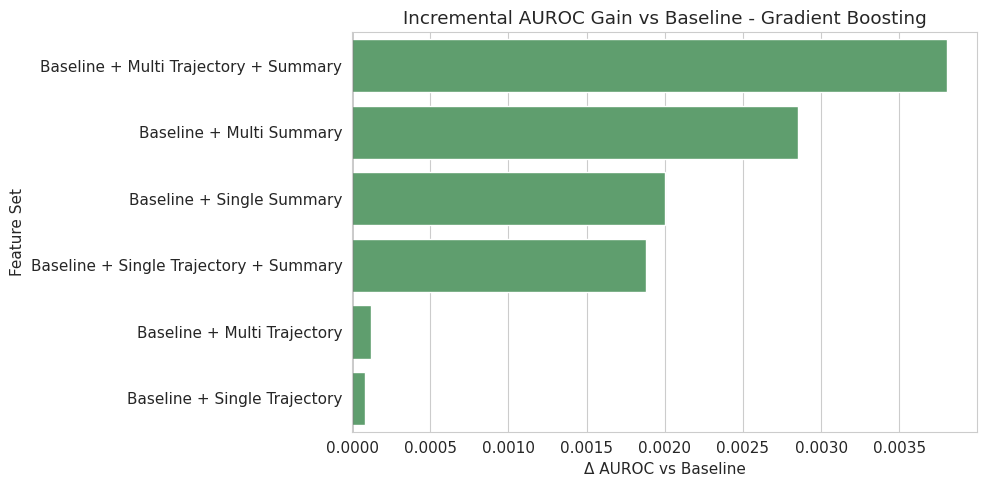

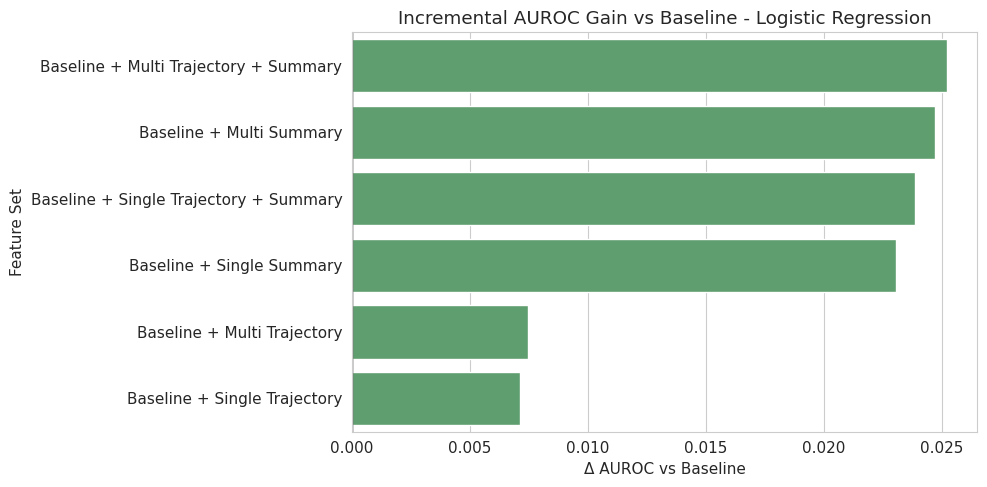

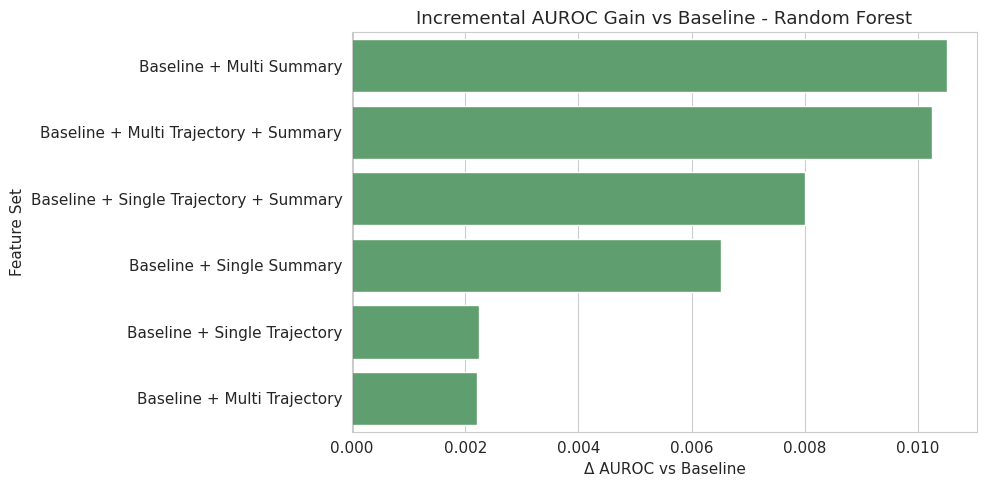

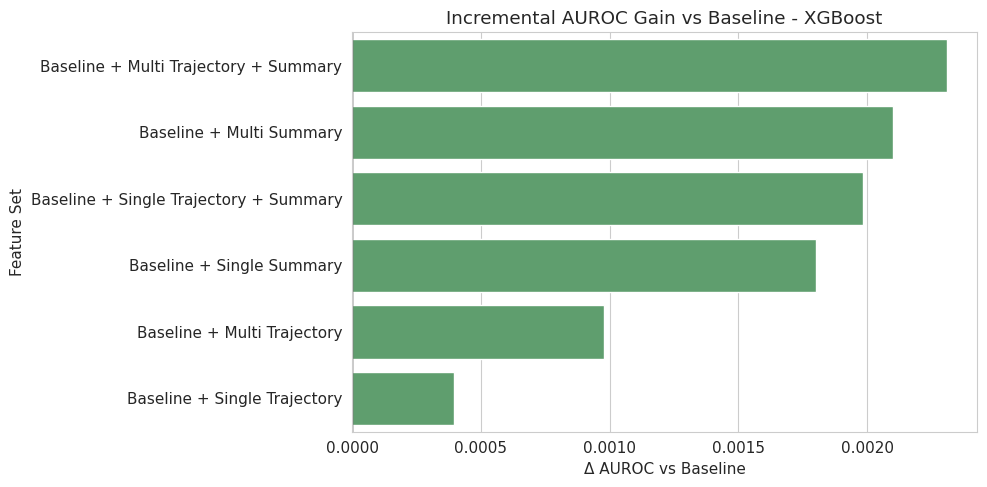

In [ ]:
# Absolute AUROC ranking per model
for model_name in summary_view['Model'].unique():
    model_df = summary_view[summary_view['Model'] == model_name].copy()
    top_df = model_df.sort_values('ROC_AUC_mean', ascending=False).head(8)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_df, x='ROC_AUC_mean', y='Feature Set', color='#4C72B0')
    plt.title(f"Top Feature Sets by AUROC - {model_name}")
    plt.xlim(0.5, 1.0)
    plt.xlabel('Mean AUROC')
    plt.tight_layout()
    plt.show()

# Delta AUROC vs baseline
for model_name in delta_view['Model'].unique():
    model_df = delta_view[delta_view['Model'] == model_name].copy().sort_values('Delta_ROC_AUC_mean', ascending=False).head(8)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=model_df, x='Delta_ROC_AUC_mean', y='Feature Set', color='#55A868')
    plt.title(f"Incremental AUROC Gain vs Baseline - {model_name}")
    plt.axvline(0, color='black', linewidth=1)
    plt.xlabel('Δ AUROC vs Baseline')
    plt.tight_layout()
    plt.show()

In [ ]:
print('=' * 100)
print('MODEL COMPARISON SUMMARY (ABSOLUTE)')
print('=' * 100)

for model_name in summary_view['Model'].unique():
    print(f"\n{model_name}:")
    model_df = summary_view[summary_view['Model'] == model_name]
    display(model_df[['Feature Set', 'ROC_AUC_mean', 'ROC_AUC_std', 'AUPR_mean', 'AUPR_std']].head(10))

print('\n' + '=' * 100)
print('INCREMENTAL BENEFIT VS BASELINE')
print('=' * 100)
for model_name in delta_view['Model'].unique():
    print(f"\n{model_name}:")
    model_df = delta_view[delta_view['Model'] == model_name]
    display(model_df[['Feature Set', 'Delta_ROC_AUC_mean', 'Delta_ROC_AUC_std', 'Delta_AUPR_mean', 'Delta_AUPR_std']].head(10))

print('\n' + '=' * 100)
print('BEST CONFIGURATION PER MODEL (BY Δ AUROC)')
print('=' * 100)
for model_name in delta_view['Model'].unique():
    model_df = delta_view[delta_view['Model'] == model_name]
    if len(model_df) == 0:
        continue
    best = model_df.sort_values('Delta_ROC_AUC_mean', ascending=False).iloc[0]
    print(
        f"{model_name}: {best['Feature Set']} "
        f"(ΔAUROC={best['Delta_ROC_AUC_mean']:.4f}, ΔAUPR={best['Delta_AUPR_mean']:.4f})"
    )

MODEL COMPARISON SUMMARY (ABSOLUTE)

Gradient Boosting:


,Feature Set,ROC_AUC_mean,ROC_AUC_std,AUPR_mean,AUPR_std
3,Baseline + Multi Trajectory + Summary,0.926232,0.007680,0.322934,0.041659
1,Baseline + Multi Summary,0.925279,0.007429,0.324793,0.042600
4,Baseline + Single Summary,0.924428,0.008706,0.320854,0.043787
6,Baseline + Single Trajectory + Summary,0.924308,0.008849,0.321208,0.044406
2,Baseline + Multi Trajectory,0.922546,0.008114,0.277894,0.034778
5,Baseline + Single Trajectory,0.922507,0.008297,0.279917,0.036282
0,Baseline,0.922425,0.007733,0.274910,0.036539



Logistic Regression:


,Feature Set,ROC_AUC_mean,ROC_AUC_std,AUPR_mean,AUPR_std
10,Baseline + Multi Trajectory + Summary,0.859794,0.009568,0.126439,0.025663
8,Baseline + Multi Summary,0.859262,0.009264,0.121663,0.023952
13,Baseline + Single Trajectory + Summary,0.858421,0.008635,0.113788,0.022621
11,Baseline + Single Summary,0.857629,0.008210,0.110225,0.020962
9,Baseline + Multi Trajectory,0.842015,0.008937,0.165497,0.031355
12,Baseline + Single Trajectory,0.841664,0.008119,0.168867,0.031558
7,Baseline,0.834550,0.007752,0.174062,0.030148



Random Forest:


...


Random Forest:


,Feature Set,Delta_ROC_AUC_mean,Delta_ROC_AUC_std,Delta_AUPR_mean,Delta_AUPR_std
12,Baseline + Multi Summary,0.010514,0.006739,0.041268,0.004841
14,Baseline + Multi Trajectory + Summary,0.010238,0.004706,0.034482,0.008086
17,Baseline + Single Trajectory + Summary,0.008009,0.005557,0.044665,0.005769
15,Baseline + Single Summary,0.006523,0.005488,0.047294,0.003454
16,Baseline + Single Trajectory,0.002245,0.002081,0.002534,0.008589
13,Baseline + Multi Trajectory,0.002207,0.003145,0.000054,0.010358



XGBoost:


,Feature Set,Delta_ROC_AUC_mean,Delta_ROC_AUC_std,Delta_AUPR_mean,Delta_AUPR_std
20,Baseline + Multi Trajectory + Summary,0.002311,0.001205,0.030953,0.003835
18,Baseline + Multi Summary,0.002101,0.001170,0.030459,0.003093
23,Baseline + Single Trajectory + Summary,0.001985,0.000344,0.031284,0.005995
21,Baseline + Single Summary,0.001801,0.000505,0.032436,0.006880
19,Baseline + Multi Trajectory,0.000978,0.001678,0.001660,0.005456
22,Baseline + Single Trajectory,0.000396,0.000598,0.000887,0.004797



BEST CONFIGURATION PER MODEL (BY Δ AUROC)
Gradient Boosting: Baseline + Multi Trajectory + Summary (ΔAUROC=0.0038, ΔAUPR=0.0480)
Logistic Regression: Baseline + Multi Trajectory + Summary (ΔAUROC=0.0252, ΔAUPR=-0.0476)
Random Forest: Baseline + Multi Summary (ΔAUROC=0.0105, ΔAUPR=0.0413)
XGBoost: Baseline + Multi Trajectory + Summary (ΔAUROC=0.0023, ΔAUPR=0.0310)
